# Portfolio Lab — EUR investor study

Run top to bottom after package installation. All calculations and safeguards live in portfolio_lab. No prices or FX are forward-filled.

In [1]:
from dataclasses import replace
from pathlib import Path
from IPython.display import display, Image
from portfolio_lab.config import load_config, configure_universe
from portfolio_lab.data import load_market_data, study_coverage
from portfolio_lab.leverage import add_leverage
from portfolio_lab.metrics import compute_asset_metrics
from portfolio_lab.optimization import optimize_frontier
from portfolio_lab.plotting import plot_frontier, plot_drawdown, allocation_summary
from portfolio_lab.reporting import write_review_outputs

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


## User configuration
Edit the universe and leverage below. Metadata and calculations use this single effective configuration. Run All after every change.

In [2]:
# Study universe: edit these metadata entries, then Run All.
assets = {'Apple': {'symbol': 'AAPL',
           'instrument': 'Primary US equity',
           'currency': 'USD',
           'return_type': 'Adjusted price',
           'distributions': 'Yahoo split/dividend adjustment; reinvestment proxy before investor tax',
           'limitation': 'Adjusted prices are a vendor proxy, not an independently audited TR index.',
           'reference': ''},
 'Nasdaq 100': {'symbol': 'QQQ',
                'instrument': 'Invesco QQQ ETF; Nasdaq-100 exposure proxy',
                'currency': 'USD',
                'return_type': 'Adjusted price',
                'distributions': 'Yahoo dividend/split adjustments; distributions assumed reinvested',
                'limitation': 'Exact Nasdaq-100 TR unavailable from tested Yahoo ^XNDX. QQQ is an ETF proxy '
                              'with fund fees/tracking differences, not the gross TR benchmark.',
                'reference': 'https://www.invesco.com/qqq-etf/en/home.html'},
 'S&P 500': {'symbol': '^SP500TR',
             'instrument': 'S&P 500 Total Return index',
             'currency': 'USD',
             'return_type': 'Gross Return',
             'distributions': 'Gross dividends reinvested by index methodology',
             'limitation': '',
             'reference': 'https://www.spglobal.com/spdji/en/indices/equity/sp-500/'},
 'Dow Jones': {'symbol': 'DIA',
               'instrument': 'State Street SPDR Dow Jones Industrial Average ETF proxy',
               'currency': 'USD',
               'return_type': 'Adjusted price',
               'distributions': 'Yahoo dividend/split adjustments; distributions assumed reinvested',
               'limitation': 'Exact Dow Jones TR unavailable from tested Yahoo ^DJITR. DIA is an ETF proxy '
                             'with fund fees/tracking differences, not the gross TR benchmark.',
               'reference': 'https://www.ssga.com/us/en/individual/etfs/state-street-spdr-dow-jones-industrial-average-etf-trust-dia'},
 'CAC 40': {'symbol': 'PX1GR.PA',
            'instrument': 'CAC 40 Gross Return Index',
            'currency': 'EUR',
            'return_type': 'Gross Return',
            'distributions': 'Gross dividends reinvested in index levels; no additional dividend adjustment',
            'limitation': 'Yahoo daily history has missing observations; inspect raw valid end and missing '
                          'counts before interpreting coverage.',
            'reference': 'https://live.euronext.com/en/product/indices/QS0011131834-XPAR'},
 'Gold': {'symbol': 'GC=F',
          'instrument': 'Yahoo continuous COMEX gold futures quotation',
          'currency': 'USD',
          'return_type': 'Price Return',
          'distributions': 'No dividends; quoted futures price changes only',
          'limitation': 'Not spot gold or an investable futures total-return index: roll, collateral yield '
                        'and contract stitching are unmodeled.',
          'reference': ''}}

# Leverage entries must reference names present in assets.
leveraged_assets = {"Apple": 1.5, "Nasdaq 100": 2.0}

# Examples (uncomment, adjust metadata, then Run All):
# del assets["Dow Jones"]
# assets["Apple"]["symbol"] = "AAPL"
# assets["MSCI World"] = dict(symbol="IWDA.AS", currency="EUR",
#     return_type="Adjusted price", instrument="iShares Core MSCI World UCITS ETF",
#     distributions="Accumulating ETF; income reinvested within the fund")
# If removing Apple: del assets["Apple"]; del leveraged_assets["Apple"]

config = configure_universe(load_config(project_dir), assets, leveraged_assets)
# Optional study overrides, applied to the same effective configuration:
# config = replace(config, risk_free_rate=0.02, frontier_points=75)


## Market data and provenance

Adjusted equity prices are a reinvestment proxy. Gross-return indices incorporate gross dividends. Gold futures quotations are not an investable total-return benchmark.

In [3]:
data = load_market_data(config)
display(data.provenance)
display(data.fx_sample)
display(study_coverage(data, config))


,Provider,Symbol,Instrument / benchmark,Return type,Native currency,Converted to,FX series used,Raw start date,Raw end date,Raw observations,Raw missing observations,FX missing on observed sessions,EUR observations,Final common start,Final common end,Final common observations,Distributions,Limitation,Reference
Asset,,,,,,,,,,,,,,,,,,,
Apple,Yahoo Finance,AAPL,Primary US equity,Adjusted price,USD,EUR,EURUSD=X,1980-12-12,2026-10-02,11544,0,5828,5716,2003-12-01,2015-12-18,2970,Yahoo split/dividend adjustment; reinvestment ...,"Adjusted prices are a vendor proxy, not an ind...",
Nasdaq 100,Yahoo Finance,QQQ,Invesco QQQ ETF; Nasdaq-100 exposure proxy,Adjusted price,USD,EUR,EURUSD=X,1999-03-10,2026-10-02,6935,0,1219,5716,2003-12-01,2015-12-18,2970,Yahoo dividend/split adjustments; distribution...,Exact Nasdaq-100 TR unavailable from tested Ya...,https://www.invesco.com/qqq-etf/en/home.html
S&P 500,Yahoo Finance,^SP500TR,S&P 500 Total Return index,Gross Return,USD,EUR,EURUSD=X,1988-01-04,2026-10-02,9761,0,4045,5716,2003-12-01,2015-12-18,2970,Gross dividends reinvested by index methodology,,https://www.spglobal.com/spdji/en/indices/equi...
Dow Jones,Yahoo Finance,DIA,State Street SPDR Dow Jones Industrial Average...,Adjusted price,USD,EUR,EURUSD=X,1998-01-20,2026-10-02,7221,0,1505,5716,2003-12-01,2015-12-18,2970,Yahoo dividend/split adjustments; distribution...,Exact Dow Jones TR unavailable from tested Yah...,https://www.ssga.com/us/en/individual/etfs/sta...
CAC 40,Yahoo Finance,PX1GR.PA,CAC 40 Gross Return Index,Gross Return,EUR,EUR,None,1987-12-31,2015-12-18,7076,2930,0,7076,2003-12-01,2015-12-18,2970,Gross dividends reinvested in index levels; no...,Yahoo daily history has missing observations; ...,https://live.euronext.com/en/product/indices/Q...
Gold,Yahoo Finance,GC=F,Yahoo continuous COMEX gold futures quotation,Price Return,USD,EUR,EURUSD=X,2000-08-30,2026-10-02,6548,83,840,5708,2003-12-01,2015-12-18,2970,No dividends; quoted futures price changes only,Not spot gold or an investable futures total-r...,


,USD value,EURUSD,Computed EUR value
Date,,,
2003-12-01,0.324669,1.196501,0.271349
2003-12-02,0.322127,1.208897,0.266463
2003-12-03,0.314500,1.212298,0.259425
2003-12-04,0.316295,1.208094,0.261813
2003-12-05,0.311807,1.218695,0.255854


{'common_start': '2003-12-01',
 'common_end': '2015-12-18',
 'common_observations': 2970,
 'latest_raw_asset_start': '2000-08-30',
 'raw_start_limiting_assets': ['Gold'],
 'earliest_raw_asset_end': '2015-12-18',
 'raw_end_limiting_assets': ['CAC 40'],
 'latest_eur_asset_start': '2003-12-01',
 'eur_start_limiting_assets': ['Apple',
  'Nasdaq 100',
  'S&P 500',
  'Dow Jones',
  'Gold'],
 'start_limiting_series': ['EURUSD=X'],
 'fx_start': '2003-12-01',
 'first_common_date_delayed_by_calendar': False}

## Daily-reset synthetic assets

Reset on every native underlying session, then translate NAV into EUR with unlevered FX. Compound before sampling common dates.

In [4]:
prices, leverage_diagnostics = add_leverage(data.common, data.native, data.fx, config)
display(leverage_diagnostics)

,Asset,Underlying,Leverage,Reset sessions,Worst underlying return,Wipeout date
0,Apple x1.5,Apple,1.5,3035,-0.179195,NaT
1,Nasdaq 100 x2,Nasdaq 100,2.0,3035,-0.089557,NaT


## Asset performance in EUR

In [5]:
stats = compute_asset_metrics(prices, config.trading_days, config.risk_free_rate, config.calendar_days_per_year)
display(stats)

,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple x1.5,0.642909,0.655551,0.543697,-0.759786,1.205729,0.846171
Apple,0.440246,0.443106,0.374333,-0.565253,1.183721,0.778847
Gold,0.093070,0.113356,0.211527,-0.373896,0.535894,0.248921
Nasdaq 100,0.115152,0.139345,0.236260,-0.468036,0.589797,0.246032
Nasdaq 100 x2,0.181751,0.260737,0.423958,-0.791747,0.615007,0.229557
Dow Jones,0.080493,0.101161,0.209625,-0.466981,0.482581,0.172369
S&P 500,0.084311,0.106731,0.218681,-0.512942,0.488068,0.164368
CAC 40,0.060170,0.085225,0.225922,-0.570832,0.377231,0.105407


## Growth frontier and volatility ceilings

Constant weights, long-only; rebalance at each common observation. Leveraged versions replace their underlying in the configured universe.

In [6]:
optimization = optimize_frontier(prices, config)
display(optimization.summary)
display(optimization.weights)
display(allocation_summary(optimization.weights, config.allocation_display_threshold))
display(optimization.dominance)

,CAGR,Mean return annualized,Volatility,Max Drawdown,Sharpe,Calmar,Success,Solver status,Status,Risk ceiling
Portfolio,,,,,,,,,,
Minimum Volatility,0.09272,0.101281,0.145655,-0.231925,0.695348,0.399784,True,0,Optimization terminated successfully,NaN
Maximum CAGR,0.642909,0.655551,0.543697,-0.759786,1.205729,0.846171,True,0,Optimization terminated successfully,NaN
Maximum Sharpe,0.365763,0.356893,0.276056,-0.419164,1.292828,0.8726,True,0,Optimization terminated successfully,NaN
Prudent,0.123288,0.130137,0.15,-0.246124,0.867583,0.500919,True,0,Optimization terminated successfully,0.15
Modéré,0.250146,0.248329,0.2,-0.319281,1.241644,0.783469,True,0,Optimization terminated successfully,0.2
Dynamique,0.397562,0.387322,0.3,-0.447148,1.291075,0.889107,True,0,Optimization terminated successfully,0.3
Agressif,0.513955,0.504116,0.4,-0.586412,1.260291,0.876441,True,0,Optimization terminated successfully,0.4
Très agressif,0.607666,0.610546,0.5,-0.715315,1.221092,0.849508,True,0,Optimization terminated successfully,0.5


,Apple x1.5,Nasdaq 100 x2,S&P 500,Dow Jones,CAC 40,Gold
Portfolio,,,,,,
Minimum Volatility,1.384167e-17,0.000000e+00,0.000000e+00,2.414892e-01,3.245581e-01,0.433953
Maximum CAGR,1.000000e+00,0.000000e+00,0.000000e+00,2.220446e-16,0.000000e+00,0.000000
Maximum Sharpe,4.532577e-01,2.321209e-17,2.388464e-17,6.630574e-18,7.878727e-02,0.467955
Prudent,5.131961e-02,3.667911e-17,1.217136e-18,1.806179e-01,3.142819e-01,0.453781
Modéré,2.616055e-01,1.343180e-16,0.000000e+00,0.000000e+00,2.441505e-01,0.494244
Dynamique,5.069574e-01,1.442468e-16,0.000000e+00,6.611383e-17,3.210388e-02,0.460939
Agressif,7.207012e-01,0.000000e+00,0.000000e+00,1.761824e-16,0.000000e+00,0.279299
Très agressif,9.169951e-01,1.477138e-17,0.000000e+00,5.640474e-17,8.935917e-19,0.083005


Portfolio
Minimum Volatility          Gold 43.4% · CAC 40 32.5% · Dow Jones 24.1%
Maximum CAGR                                          Apple x1.5 100.0%
Maximum Sharpe              Gold 46.8% · Apple x1.5 45.3% · CAC 40 7.9%
Prudent               Gold 45.4% · CAC 40 31.4% · Dow Jones 18.1% · ...
Modéré                     Gold 49.4% · Apple x1.5 26.2% · CAC 40 24.4%
Dynamique                   Apple x1.5 50.7% · Gold 46.1% · CAC 40 3.2%
Agressif                                  Apple x1.5 72.1% · Gold 27.9%
Très agressif                              Apple x1.5 91.7% · Gold 8.3%
dtype: object

,100% CAGR,100% volatility,Frontier CAGR,Frontier volatility
Asset,,,,
Apple x1.5,0.642909,0.543697,0.642909,0.543697
Nasdaq 100 x2,0.181751,0.423958,0.538159,0.423958
S&P 500,0.084311,0.218681,0.281786,0.218681
Dow Jones,0.080493,0.209625,0.266867,0.209625
CAC 40,0.060170,0.225922,0.293269,0.225922
Gold,0.093070,0.211527,0.270059,0.211527


## Charts

In [7]:
frontier_figure = plot_frontier(stats, optimization)
drawdown_figure = plot_drawdown(stats)

## Export evidence and validate numerical results

{'portfolio_weight_sums': {'Minimum Volatility': 1.0,
  'Maximum CAGR': 1.0,
  'Maximum Sharpe': 0.9999999999999998,
  'Prudent': 1.0,
  'Modéré': 1.0,
  'Dynamique': 1.0,
  'Agressif': 1.0,
  'Très agressif': 1.0,
  'Frontier 0': 1.0,
  'Frontier 1': 1.0,
  'Frontier 2': 1.0000000000000002,
  'Frontier 3': 1.0,
  'Frontier 4': 1.0,
  'Frontier 5': 1.0,
  'Frontier 6': 1.0,
  'Frontier 7': 1.0,
  'Frontier 8': 1.0,
  'Frontier 9': 1.0,
  'Frontier 10': 1.0,
  'Frontier 11': 1.0,
  'Frontier 12': 1.0,
  'Frontier 13': 1.0,
  'Frontier 14': 1.0,
  'Frontier 15': 1.0,
  'Frontier 16': 1.0,
  'Frontier 17': 1.0,
  'Frontier 18': 0.9999999999999999,
  'Frontier 19': 1.0,
  'Frontier 20': 1.0,
  'Frontier 21': 1.0,
  'Frontier 22': 1.0,
  'Frontier 23': 1.0,
  'Frontier 24': 1.0,
  'Frontier 25': 1.0,
  'Frontier 26': 1.0,
  'Frontier 27': 1.0,
  'Frontier 28': 0.9999999999999998,
  'Frontier 29': 0.9999999999999999,
  'Frontier 30': 1.0,
  'Frontier 31': 1.0,
  'Frontier 32': 1.0,
  'Fronti

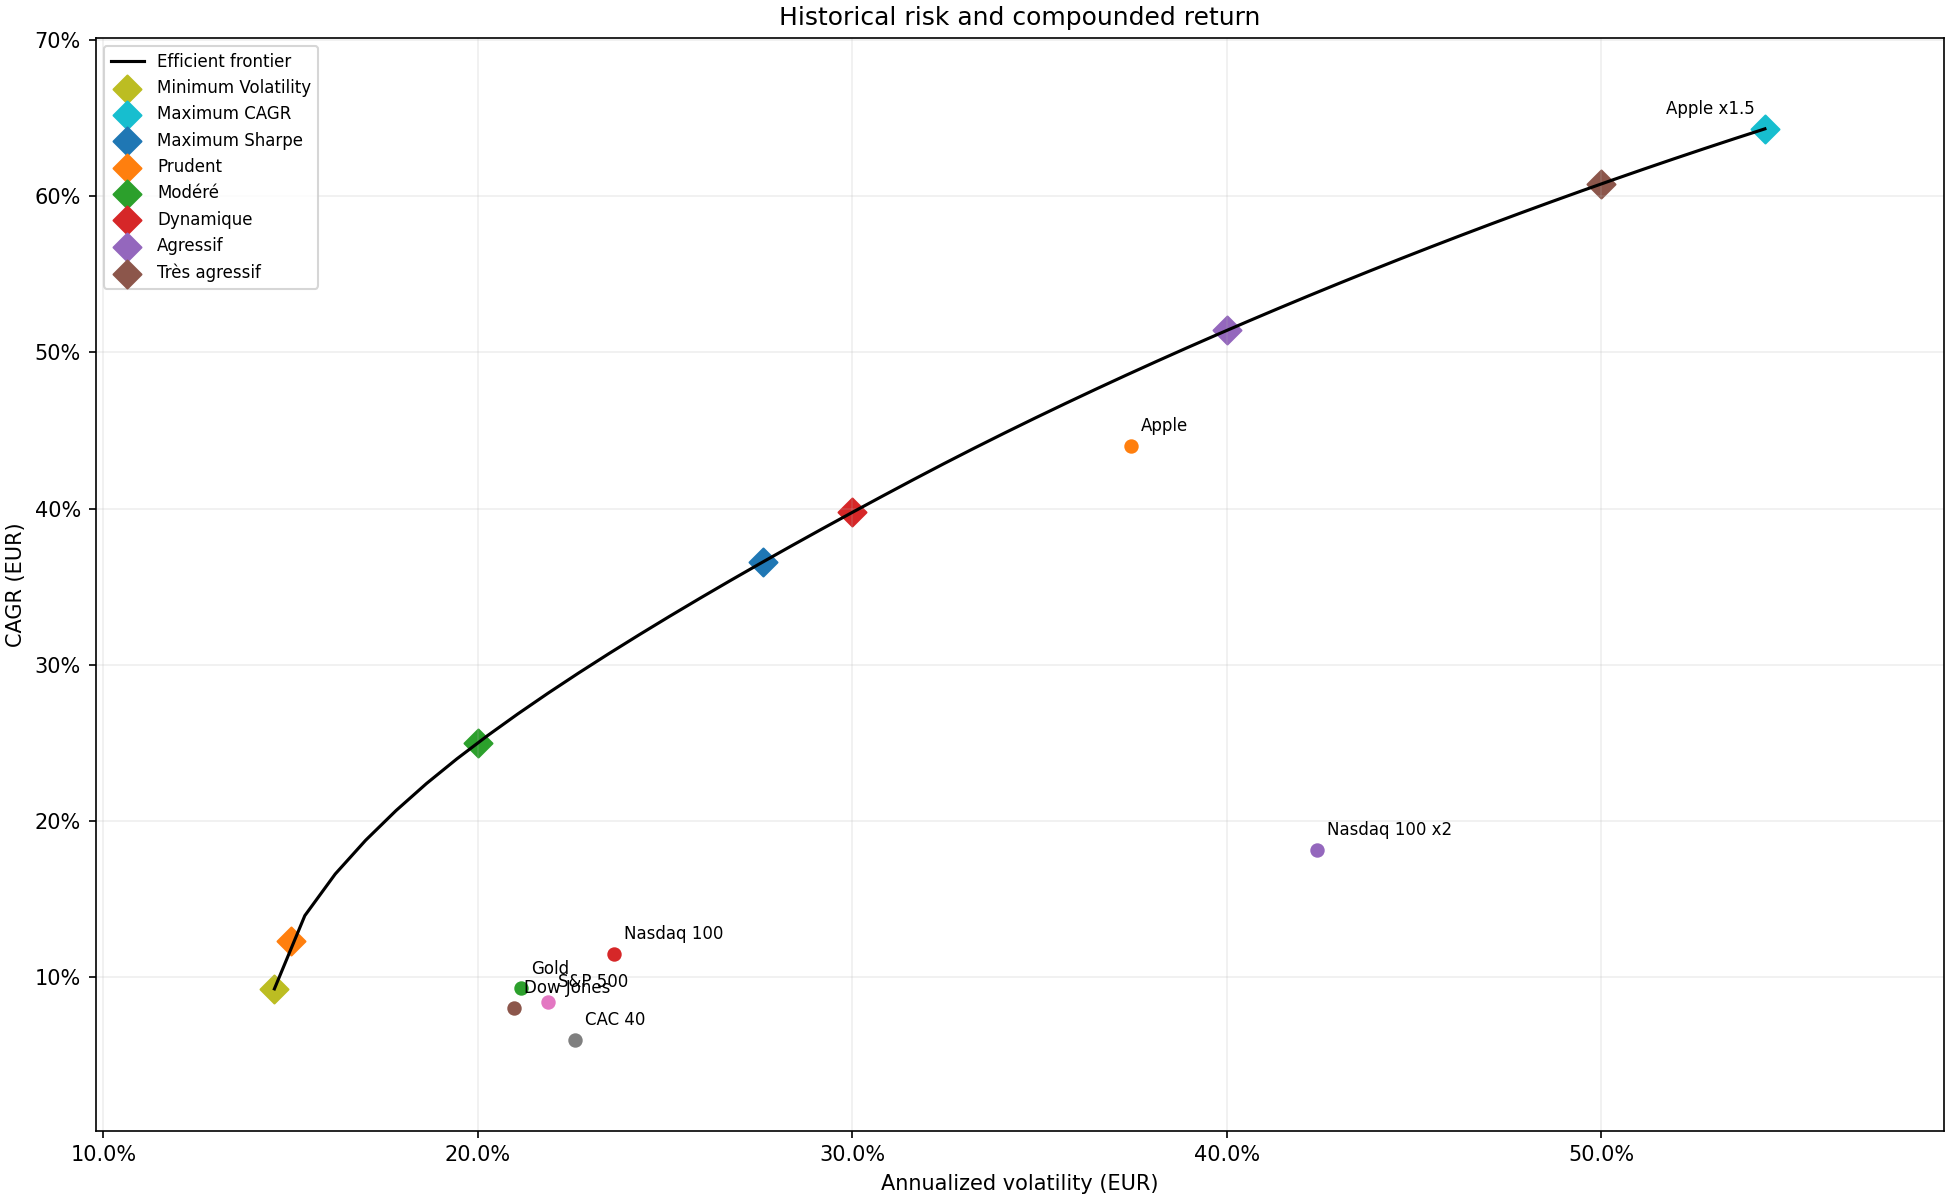

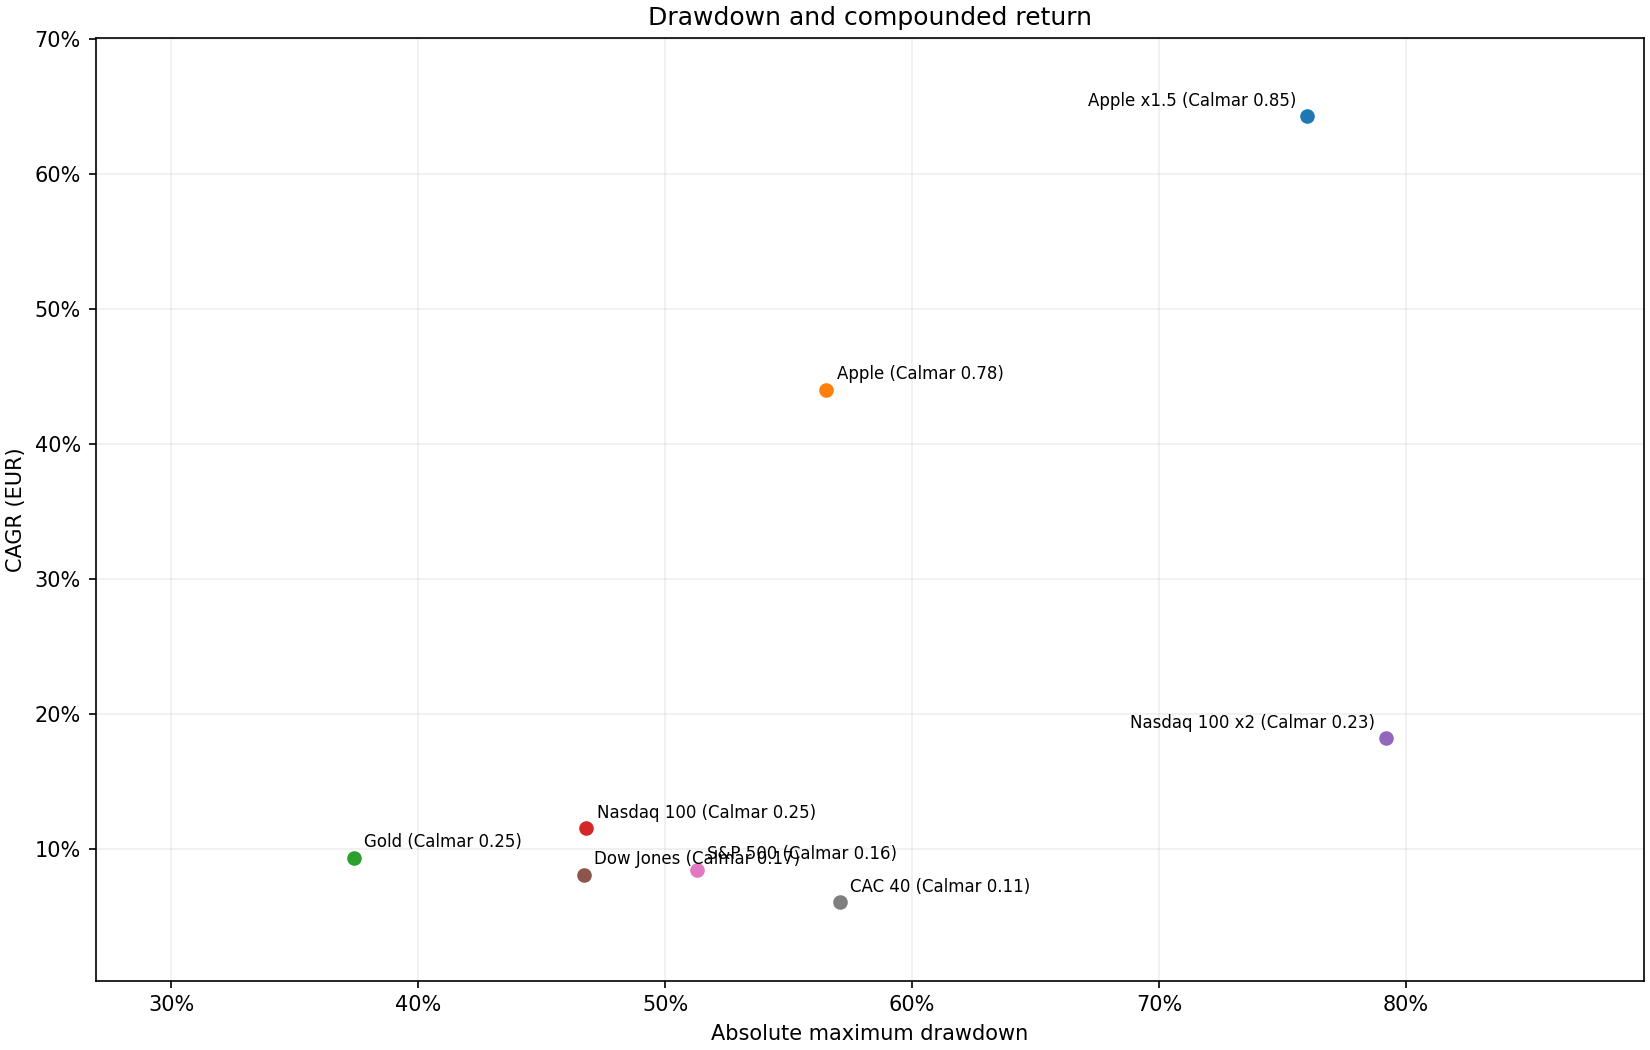

In [8]:
sanity = write_review_outputs(data, prices, stats, leverage_diagnostics, optimization, config)
frontier_figure.savefig(config.output_dir / "frontier.png", dpi=150)
drawdown_figure.savefig(config.output_dir / "drawdown.png", dpi=150)
display(sanity)
display(Image(filename=str(config.output_dir / "frontier.png")))
display(Image(filename=str(config.output_dir / "drawdown.png")))
